<a href="https://colab.research.google.com/github/MuchnikJansyG/AnalisisDatosMasivos1/blob/main/Actividad1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Listar los archivos que están en la carpeta principal
list.files("/content")

[1] "sample_data"                                          
[2] "Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv"

In [ ]:
# Instalación de librerías si no están presentes
if(!require(tidyverse)) install.packages("tidyverse")
if(!require(ggpubr)) install.packages("ggpubr")

library(tidyverse)
library(ggpubr)

# Cargar el dataset (asegúrate de haber subido el archivo a Colab)
df <- read.csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

# Visualizar estructura
str(df)

Loading required package: tidyverse

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: ggpubr

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘ggpubr’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doB

'data.frame':	7500 obs. of  16 variables:
 $ transaction_id         : chr  "TXN00001" "TXN00002" "TXN00003" "TXN00004" ...
 $ user_id                : chr  "U00001" "U00002" "U00003" "U00004" ...
 $ age                    : int  21 24 31 32 25 26 25 26 21 35 ...
 $ gender                 : chr  "Male" "Other" "Other" "Other" ...
 $ daily_screen_time_hours: num  3.23 5.09 6.06 7.83 9.96 9.32 10.4 4.26 4.38 9.76 ...
 $ social_media_hours     : num  2.01 3.81 1.36 5.85 5.92 4.26 4.93 4.6 1.38 4.73 ...
 $ gaming_hours           : num  0.89 2.24 3.83 1.51 3.42 0.29 1.6 2.16 2.72 1.36 ...
 $ work_study_hours       : num  4.55 4.44 2.35 3.54 5.27 3.99 0.86 4.61 3.78 2.11 ...
 $ sleep_hours            : num  7.55 7.66 4.92 8.23 6.21 6.9 8.61 6.43 6.23 5.21 ...
 $ notifications_per_day  : int  248 127 44 178 136 82 165 169 172 20 ...
 $ app_opens_per_day      : int  154 71 106 107 177 56 95 117 134 82 ...
 $ weekend_screen_time    : num  3.95 6.71 8.68 9.77 12.55 ...
 $ stress_level           :

Problema: Investigar si la media de tiempo de pantalla diario es diferente de 7 horas (el estándar hipotético).

Media observada de horas de pantalla: 7.499912 
Desviación estándar: 2.609188 
Valor mínimo: 3 
Valor máximo: 12 


	One Sample t-test

data:  df$daily_screen_time_hours
t = 16.593, df = 7499, p-value < 2.2e-16
alternative hypothesis: true mean is not equal to 7
95 percent confidence interval:
 7.440852 7.558972
sample estimates:
mean of x 
 7.499912 



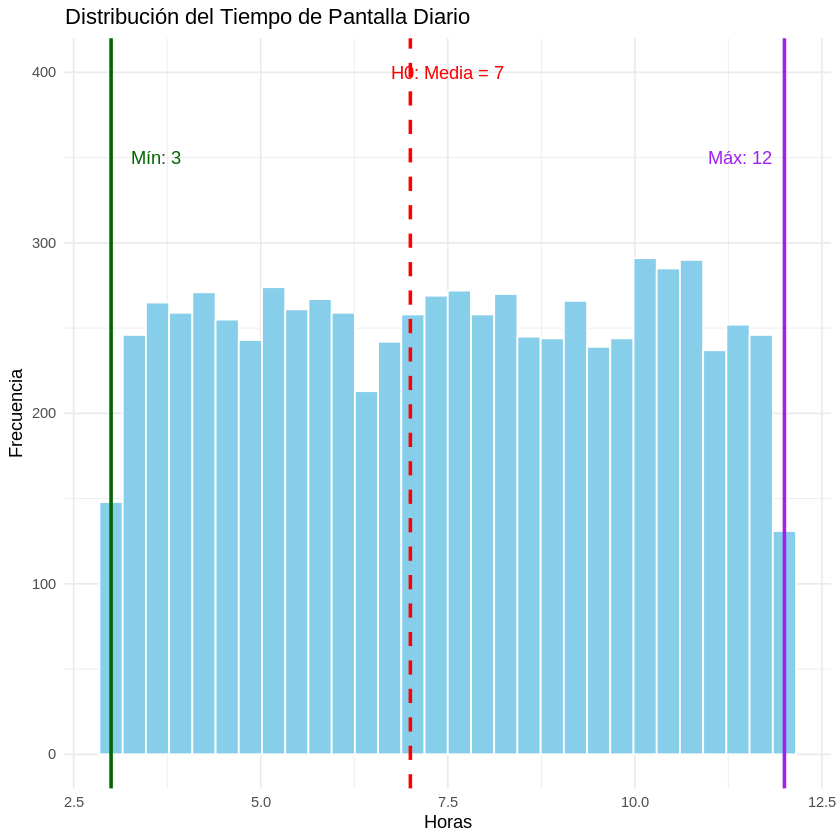

In [ ]:
# =====================================================================
# CELDA 2: ESCENARIO 1 - Estudio de una población (Tiempo de pantalla)
# =====================================================================

# --- 1. ESTADÍSTICA DESCRIPTIVA ---
media_pantalla <- mean(df$daily_screen_time_hours)
sd_pantalla <- sd(df$daily_screen_time_hours)
minimo_pantalla <- min(df$daily_screen_time_hours)
maximo_pantalla <- max(df$daily_screen_time_hours)

cat("Media observada de horas de pantalla:", media_pantalla, "\n")
cat("Desviación estándar:", sd_pantalla, "\n")
cat("Valor mínimo:", minimo_pantalla, "\n")
cat("Valor máximo:", maximo_pantalla, "\n\n")

# --- 2. VISUALIZACIÓN ---
ggplot(df, aes(x = daily_screen_time_hours)) +
  geom_histogram(fill = "skyblue", color = "white", bins = 30) +

  # 1. Línea y texto para la Hipótesis Nula (Rojo)
  geom_vline(aes(xintercept = 7), color = "red", linetype = "dashed", linewidth = 1) +
  annotate("text", x = 7.5, y = 400, label = "H0: Media = 7", color = "red") +

  # 2. Línea y texto para el Mínimo (Verde oscuro)
  geom_vline(aes(xintercept = min(daily_screen_time_hours)), color = "darkgreen", linetype = "solid", linewidth = 1) +
  annotate("text", x = minimo_pantalla + 0.6, y = 350, label = paste("Mín:", minimo_pantalla), color = "darkgreen") +

  # 3. Línea y texto para el Máximo (Morado)
  geom_vline(aes(xintercept = max(daily_screen_time_hours)), color = "purple", linetype = "solid", linewidth = 1) +
  annotate("text", x = maximo_pantalla - 0.6, y = 350, label = paste("Máx:", maximo_pantalla), color = "purple") +

  # Etiquetas generales del gráfico
  labs(title = "Distribución del Tiempo de Pantalla Diario",
       x = "Horas", y = "Frecuencia") +
  theme_minimal()

# --- 3. CONTRASTE DE HIPÓTESIS ---
# Prueba t para una muestra (H0: mu = 7)
test_una_poblacion <- t.test(df$daily_screen_time_hours, mu = 7)
print(test_una_poblacion)

Problema: Comparar si las horas de sueño varían significativamente entre usuarios adictos y no adictos.

[1] "Resumen Completo de Horas de Sueño por Grupo:"
# A tibble: 2 × 5
  addicted_label Media Desv_Estandar Minimo Maximo
  <fct>          <dbl>         <dbl>  <dbl>  <dbl>
1 NA              6.67          1.28    4.5      9
2 NA              6.77          1.28    4.5      9

--- RESULTADOS DEL CONTRASTE DE HIPÓTESIS ---

	Welch Two Sample t-test

data:  sleep_hours by addicted_label
t = -3.0802, df = 4099.9, p-value = 0.002083
alternative hypothesis: true difference in means between group No Adicto and group Adicto is not equal to 0
95 percent confidence interval:
 -0.16393483 -0.03641235
sample estimates:
mean in group No Adicto    mean in group Adicto 
               6.666665                6.766839 



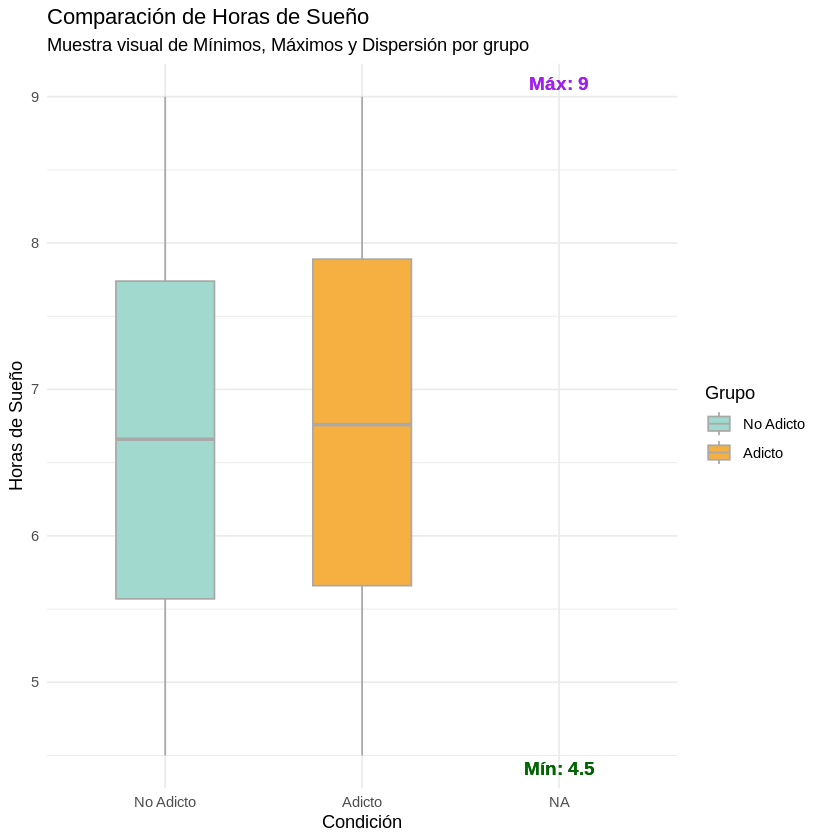

In [ ]:
# =====================================================================
# ESCENARIO 2: Comparación de dos poblaciones (Sueño vs. Adicción)
# =====================================================================
# --- 1. ESTADÍSTICA DESCRIPTIVA (CON MÍNIMO Y MÁXIMO) ---
resumen_sueno <- df %>%
  group_by(addicted_label) %>%
  summarise(
    Media = mean(sleep_hours),
    Desv_Estandar = sd(sleep_hours),
    Minimo = min(sleep_hours),
    Maximo = max(sleep_hours)
  )

# Convertimos el 0 y 1 a texto para que coincida con el gráfico
resumen_sueno$addicted_label <- factor(resumen_sueno$addicted_label, levels = c(0, 1), labels = c("No Adicto", "Adicto"))

print("Resumen Completo de Horas de Sueño por Grupo:")
print(resumen_sueno)
cat("\n")

# --- 2. VISUALIZACIÓN (CON ETIQUETAS DE MÍNIMO Y MÁXIMO) ---
ggplot() +
  # 1. Dibujamos las cajas usando la base de datos original (df)
  geom_boxplot(data = df, aes(x = as.factor(addicted_label), y = sleep_hours, fill = as.factor(addicted_label)),
               width = 0.5, color = "darkgray") +

  # 2. Añadimos el texto del MÍNIMO usando la tablita de resumen (Verde)
  geom_text(data = resumen_sueno,
            aes(x = addicted_label, y = Minimo, label = paste("Mín:", Minimo)),
            vjust = 1.5, color = "darkgreen", fontface = "bold", size = 4) +

  # 3. Añadimos el texto del MÁXIMO usando la tablita de resumen (Morado)
  geom_text(data = resumen_sueno,
            aes(x = addicted_label, y = Maximo, label = paste("Máx:", Maximo)),
            vjust = -0.5, color = "purple", fontface = "bold", size = 4) +

  # Etiquetas y diseño general
  labs(title = "Comparación de Horas de Sueño",
       subtitle = "Muestra visual de Mínimos, Máximos y Dispersión por grupo",
       x = "Condición",
       y = "Horas de Sueño",
       fill = "Grupo") +
  theme_minimal() +
  scale_fill_manual(values = c("#A2D9CE", "#F5B041"), labels = c("No Adicto", "Adicto")) +
  scale_x_discrete(labels = c("No Adicto", "Adicto"))

# --- 3. CONTRASTE DE HIPÓTESIS ---
cat("--- RESULTADOS DEL CONTRASTE DE HIPÓTESIS ---\n")
test_dos_poblaciones <- t.test(sleep_hours ~ addicted_label, data = df)
print(test_dos_poblaciones)